## Анализ и прогнозирование временных рядов методами искусственного интеллекта

### **Практическая работа 7. Востановление пропусков и прогноз значений временного ряда.**


#### **7.1 Аналитечкие методы востановления временного ряда**

##### *Краткое описание*

В данном пункте практической работы вам предстоит познакомиться с базовыми, аналитическими методами восстановления временных рядов.
Для выполнения данного пункта из каждой группы методов, представленных в ***табл. 7.1*** вам необходимо выбрать по одному методу восстановления ряда. При работе с первой группой, вам необходимо самостоятельно реализовать выбранный метод.  

**Табл. 7.1** - Группы аналитических методов восстановления.
№|Название группы|Модели и методы|
--|----|----|
1|Заполнение существующими значениями ряда|Средним, медианной, Hot-Deck|
2|Заполнение на основе близки значений|[Интерполяция](https://scikit-learn.org/stable/auto_examples/linear_model/plot_polynomial_interpolation.html),  [KNNi](https://scikit-learn.org/stable/modules/generated/sklearn.impute.KNNImputer.html)|
3|На основе матричных разложений|[CD-Rec](#Fixme:Дат ссылку), [SVD](https://pypi.org/project/fancyimpute/)|

##### 7.1.1 Загрузка и подготовка данных

In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from google.colab import drive
drive.mount('/gdrive')

Mounted at /gdrive


In [3]:
ts_url = '/gdrive/My Drive/Colab Notebooks/АиПВРМИИ/07/madrid.txt' # для colab
#path_data = Path('Dataset')/'madrid.txt'
madrid = np.loadtxt(ts_url)[:,0]
print(madrid.shape)

(25000,)


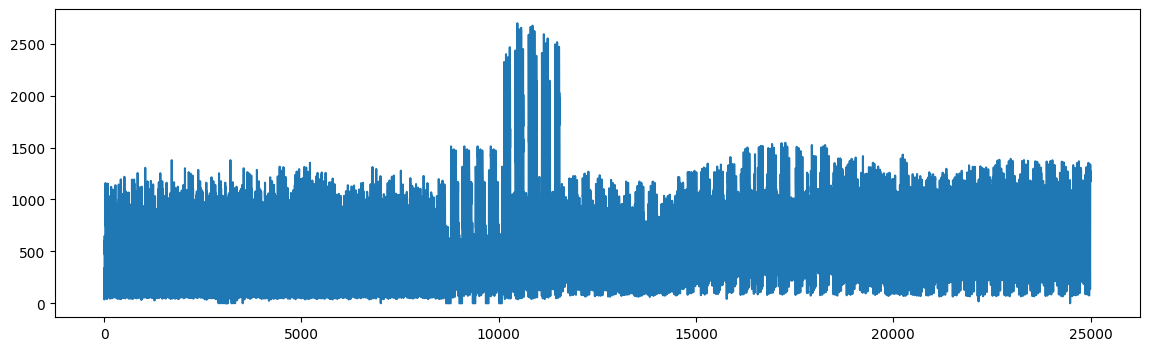

In [4]:
fig, ax =  plt.subplots(figsize=(14,4),ncols=1,nrows=1)
plt.plot(madrid[:])
plt.show()

Самостоятельно реализуйте функцию, принимающую на вход многомерный временной ряд и возвращающий:
1. Все подпоследовательности временного ряда, в которых некоторые значения временного ряда были заменены nan значениями.
2. Индексы пропущенных значений
   
Процент пропущенных значений должен регулироваться отдельным параметром.


In [28]:
import torch
def add_nan(x, percent=0.25):
    """
    Заменяет указанный процент значений в тензоре на NaN.

    Args:
        x (torch.Tensor): Входной многомерный временной ряд.
        percent (float): Процент значений для замены на NaN (от 0.0 до 1.0).

    Returns:
        tuple:
            - torch.Tensor: Тензор с замененными значениями.
            - torch.Tensor: Булева маска с индексами замененных значений.
    """
    # Создаем копию входного тензора, чтобы не изменять оригинал
    x_with_nan = x.copy()

    # Общее количество элементов в тензоре. [6, 7, 10, 11, 13]
    total_elements = x.size

    # Количество элементов для замены
    num_to_replace = int(total_elements * percent)

    # Генерируем случайную перестановку индексов от 0 до общего количества элементов. [1, 8, 12, 14, 16]
    indices = np.random.choice(np.arange(total_elements), size=num_to_replace, replace=False)

    # Создаем булеву маску для индексации
    nan_mask = np.zeros(total_elements, dtype=bool)
    nan_mask[indices] = True

    # Изменяем форму маски, чтобы она соответствовала форме входного тензора
    nan_mask = nan_mask.reshape(x.shape)

    # Заменяем значения по маске на NaN
    x_with_nan[nan_mask] = np.nan

    return x_with_nan, nan_mask


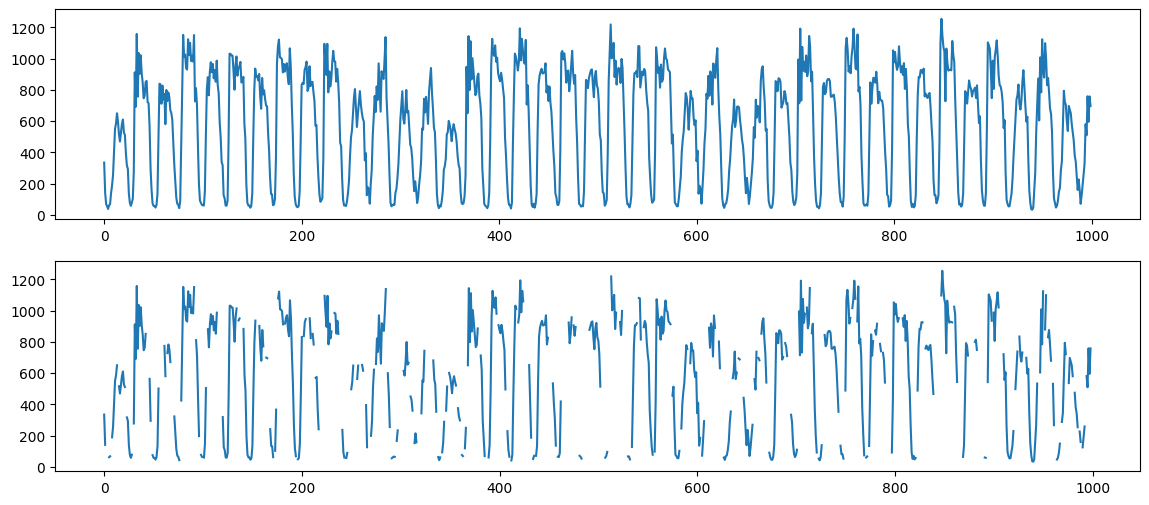

In [29]:
madrid_with_nan, index = add_nan(madrid)
fig, ax =  plt.subplots(figsize=(14,6),ncols=1,nrows=2)
ax[0].plot(madrid[:1000])
ax[1].plot(madrid_with_nan[:1000])
plt.show()

In [30]:
recovery = {}

##### 7.1.2 Заполнение существующими значениями ряда


In [31]:
madrid_mean = madrid_with_nan.copy()
madrid_mean[index] = np.nanmean(madrid_mean)
recovery['mean'] = madrid_mean

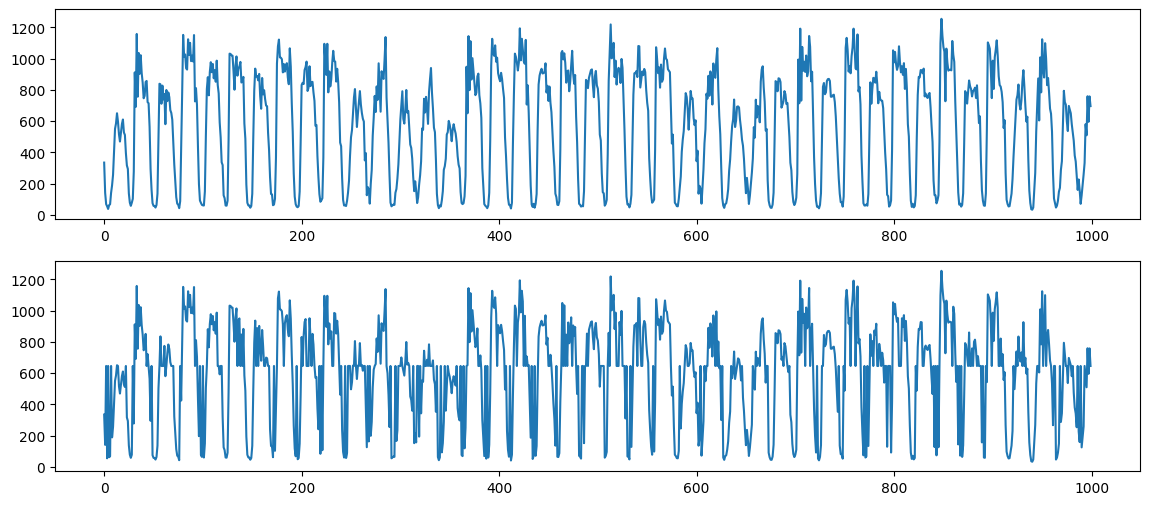

In [32]:
fig, ax =  plt.subplots(figsize=(14,6),ncols=1,nrows=2)
ax[0].plot(madrid[:1000])
ax[1].plot(madrid_mean[:1000])
plt.show()

In [33]:
madrid_median = madrid_with_nan.copy()
madrid_median[index] = np.nanmedian(madrid_median)

In [34]:
recovery['median'] = madrid_median

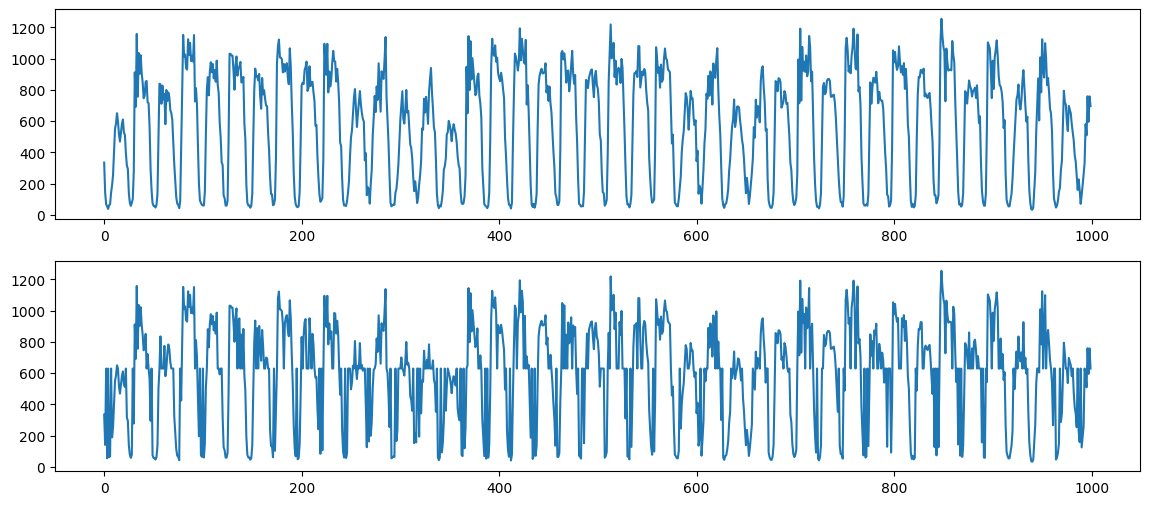

In [35]:
#madrid_with_nan, index = add_nan(madrid)
fig, ax =  plt.subplots(figsize=(14,6),ncols=1,nrows=2)
ax[0].plot(madrid[:1000])
ax[1].plot(madrid_median[:1000])
plt.show()

Самостоятельно реализуйте один метод из первой группы ***табл. 7.1*** и проведите постановление данных, сохранив результаты восстановления.

In [36]:
madrid_hotdeck = madrid_with_nan.copy()

# Находим значения, которые не являются NaN, чтобы использовать их в качестве "доноров"
donors = madrid_hotdeck[~np.isnan(madrid_hotdeck)]

# Определяем количество пропущенных значений, которые нужно заменить
n_missing = np.sum(index)

# Выбираем случайные значения из доноров.
# replace=True означает, что одно и то же значение-донор может быть использовано несколько раз.
imputed_values = np.random.choice(donors, size=n_missing, replace=True)

# Заполняем пропуски (NaN) в нашем массиве выбранными значениями.
madrid_hotdeck[index] = imputed_values

In [37]:
recovery['hotdeck'] = madrid_hotdeck

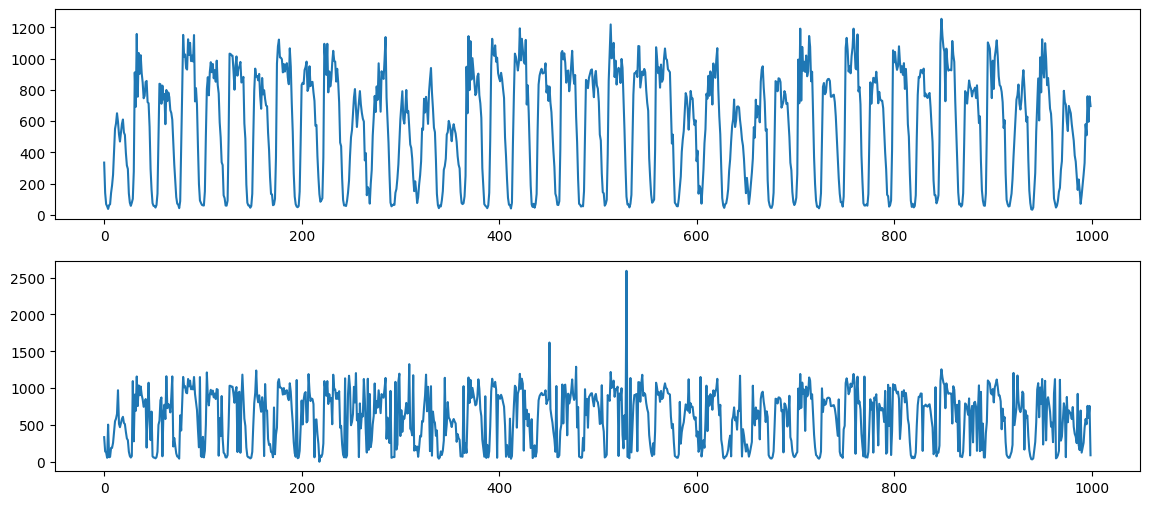

In [38]:
#madrid_with_nan, index = add_nan(madrid)
fig, ax =  plt.subplots(figsize=(14,6),ncols=1,nrows=2)
ax[0].plot(madrid[:1000])
ax[1].plot(madrid_hotdeck[:1000])
plt.show()

##### 7.1.3 Заполнение на основе близких значений


Используя документацию одного из методов восстановления второй группы ***табл. 7.1*** и проведите восстановление данных, сохранив результаты восстановления.

In [39]:
from sklearn.impute import KNNImputer

In [40]:
def rolling_window(a, window, intersection=False):
    # result = torch.zeros(size=(a.shape[0],a.shape[1]))
    returns = []
    if intersection:
        for i in range(0, a.shape[0]-window):
            returns.append(a[i:i + window])
    else:
        for i in range(0, a.shape[0],window):
            returns.append(a[i:i + window])
    return np.stack(returns)
madrid_slice = rolling_window(madrid_with_nan, 100)


In [41]:
madrid_slice = rolling_window(madrid_with_nan, 100)

Форма исходного массива: (25000,)
Форма массива после нарезки на окна: (250, 100)
Форма восстановленного массива: (25000,)


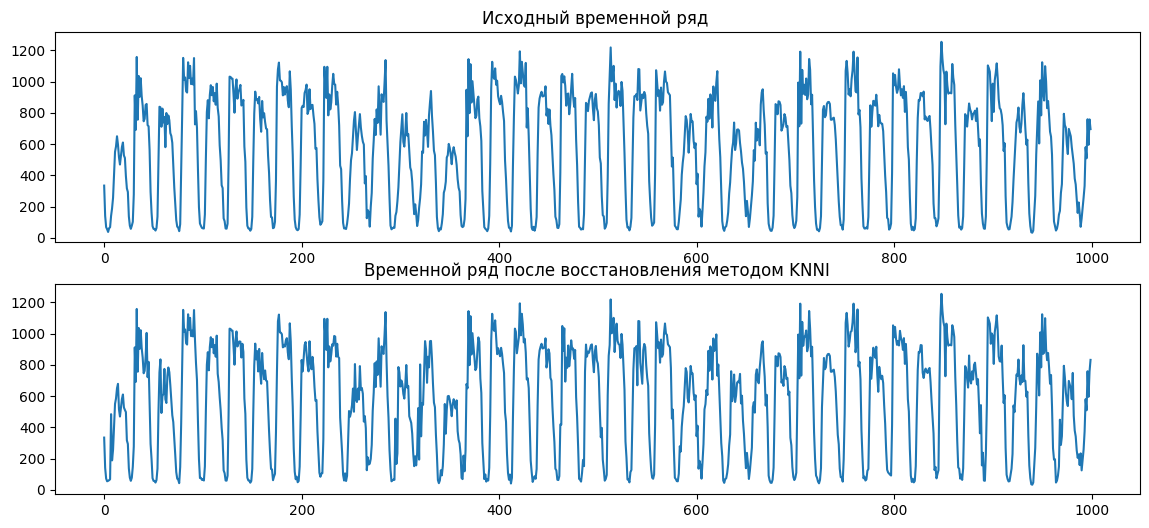

In [43]:
# Создаем экземпляр KNNImputer
# n_neighbors=5 означает, что для заполнения пропуска будут использоваться 5 ближайших соседей (окон).
imputer = KNNImputer(n_neighbors=5)

# Применяем импьютер к нашим данным, нарезанным на окна
# Метод fit_transform вычисляет соседей и сразу же заполняет пропуски
madrid_slice_imputed = imputer.fit_transform(madrid_slice)

# Склеиваем окна обратно в единый временной ряд
# Используем reshape(-1) для преобразования 2D массива обратно в 1D
madrid_knn = madrid_slice_imputed.reshape(-1)

# Убедимся, что длина восстановленного ряда соответствует исходной
madrid_knn = madrid_knn[:madrid.shape[0]]

recovery['knn'] = madrid_knn

print("Форма исходного массива:", madrid_with_nan.shape)
print("Форма массива после нарезки на окна:", madrid_slice.shape)
print("Форма восстановленного массива:", madrid_knn.shape)

fig, ax = plt.subplots(figsize=(14, 6), ncols=1, nrows=2)
ax[0].plot(madrid[:1000])
ax[0].set_title("Исходный временной ряд ")

ax[1].plot(madrid_knn[:1000])
ax[1].set_title("Временной ряд после восстановления методом KNNI")
plt.show()

##### 7.1.4 Заполнение на матричных преобразований

Используя документацию одного из методов восстановления третей группы ***табл. 7.1*** и проведите восстановление данных, сохранив результаты восстановления.

In [44]:
!pip install fancyimpute

  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 9.5 MB/s eta 0:00:00
  Created wheel for fancyimpute: filename=fancyimpute-0.7.0-py3-none-any.whl size=29879 sha256=33d449253239c4577a115974afaef3210de0d07b031d3366b55ef2232ee00a5b
  Stored in directory: /root/.cache/pip/wheels/df/20/91/e4850b9a31cf660c1bc95515d3bcbc8010e869e5de6d5baf07
  Created wheel for knnimpute: filename=knnimpute-0.1.0-py3-none-any.whl size=11331 sha256=f10b2964d5e6a3f3bde7f4a764ef5076aec40420e5bbfe1ef788a747751ea5d9
  Stored in directory: /root/.cache/pip/wheels/89/11/61/aa5a3167bfff49218cd043a73a83034b9eadd858b0059521be
Successfully built fancyimpute knnimpute


In [45]:
from fancyimpute import IterativeSVD

In [46]:
from sklearn.metrics import mean_squared_error

/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


[IterativeSVD] Iter 1: observed MAE=345.888929
[IterativeSVD] Iter 2: observed MAE=268.698371
[IterativeSVD] Iter 3: observed MAE=188.880180
[IterativeSVD] Iter 4: observed MAE=116.555330
[IterativeSVD] Iter 5: observed MAE=100.974345
[IterativeSVD] Iter 6: observed MAE=99.292427
[IterativeSVD] Iter 7: observed MAE=98.958887
[IterativeSVD] Iter 8: observed MAE=98.900268
[IterativeSVD] Iter 9: observed MAE=98.907091
[IterativeSVD] Iter 10: observed MAE=98.924020
[IterativeSVD] Iter 11: observed MAE=98.940915
MSE на пропущенных значениях: 29136.84


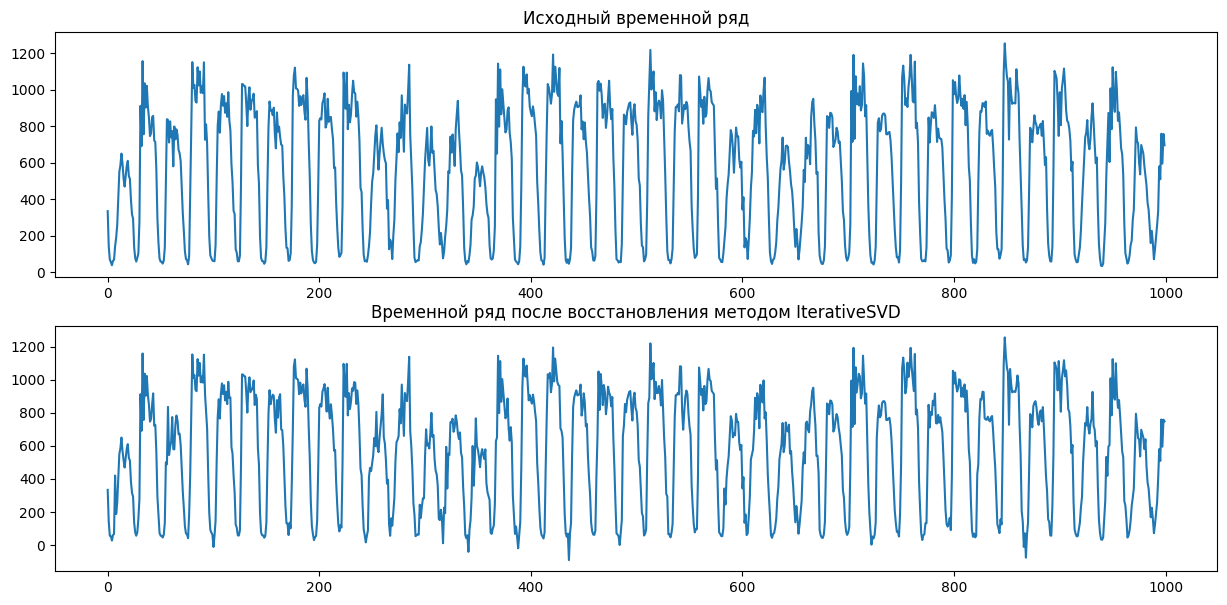

In [49]:
# Создаем экземпляр IterativeSVD
# rank - это ранг матриц, используемых для аппроксимации.
# Это ключевой гиперпараметр, который влияет на качество восстановления.
# Начнем с ранга, равного 10.
svd_imputer = IterativeSVD(rank=10)

# Применяем импьютер к нашим данным, нарезанным на окна
# Метод fit_transform выполняет итеративное восстановление.
madrid_slice_imputed_svd = svd_imputer.fit_transform(madrid_slice)

# Склеиваем окна обратно в единый временной ряд
# Используем reshape(-1) для преобразования массива обратно в 1D
madrid_svd = madrid_slice_imputed_svd.reshape(-1)

# Убедимся, что длина восстановленного ряда соответствует исходной
madrid_svd = madrid_svd[:madrid.shape[0]]

recovery['svd'] = madrid_svd

mse_svd = mean_squared_error(madrid[index], madrid_svd[index])
print(f"MSE на пропущенных значениях: {mse_svd:.2f}")

fig, ax = plt.subplots(figsize=(15, 7), ncols=1, nrows=2)
ax[0].plot(madrid[:1000])
ax[0].set_title("Исходный временной ряд")

ax[1].plot(madrid_svd[:1000])
ax[1].set_title("Временной ряд после восстановления методом IterativeSVD")
plt.show()

##### 7.1.5 Сравнение результатов восстановления.

Для каждой группы методов постройте методов основные метрики оценки качества постановления.
На основе метрик отберите лучшие методы постановления метрик и выберите лучшую группу методов.
Для лучших методов из каждой группы постройте графики сравнения реальных и восстановленных данных. Объясните результаты и сделайте вывод.



MAE (Mean Absolute Error): Средняя абсолютная разница между реальным и восстановленным значением. Показывает среднюю величину ошибки.

MSE (Mean Squared Error): Средний квадрат разницы. Сильнее штрафует за большие ошибки.

RMSE (Root Mean Squared Error): Корень из MSE. Приводит метрику к той же размерности, что и исходные данные, что делает ее более интерпретируемой.

In [51]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
# Словарь для хранения результатов
metrics = {}

# Исходные значения, которые были заменены на NaN
original_values = madrid[index]

for method_name, restored_array in recovery.items():
    # Восстановленные значения в местах пропусков
    imputed_values = restored_array[index]

    # Расчет метрик
    mae = mean_absolute_error(original_values, imputed_values)
    mse = mean_squared_error(original_values, imputed_values)
    rmse = np.sqrt(mse)

    metrics[method_name] = {'MAE': mae, 'MSE': mse, 'RMSE': rmse}

# Вывод результатов в виде таблицы
print("-" * 55)
print(f"{'Метод':<15} | {'MAE':>10} | {'MSE':>12} | {'RMSE':>10}")
print("-" * 55)
for method_name, values in metrics.items():
    print(f"{method_name:<15} | {values['MAE']:>10.2f} | {values['MSE']:>12.2f} | {values['RMSE']:>10.2f}")
print("-" * 55)

-------------------------------------------------------
Метод           |        MAE |          MSE |       RMSE
-------------------------------------------------------
mean            |     334.29 |    154908.73 |     393.58
median          |     334.29 |    155301.26 |     394.08
hotdeck         |     444.20 |    304390.31 |     551.72
knn             |     137.69 |     39850.58 |     199.63
svd             |     123.38 |     29136.84 |     170.70
-------------------------------------------------------


Лучшие методы в каждой группе (по RMSE):
- Группа 1: Существующие значения: mean
- Группа 2: Близкие значения: knn
- Группа 3: Матричные разложения: svd


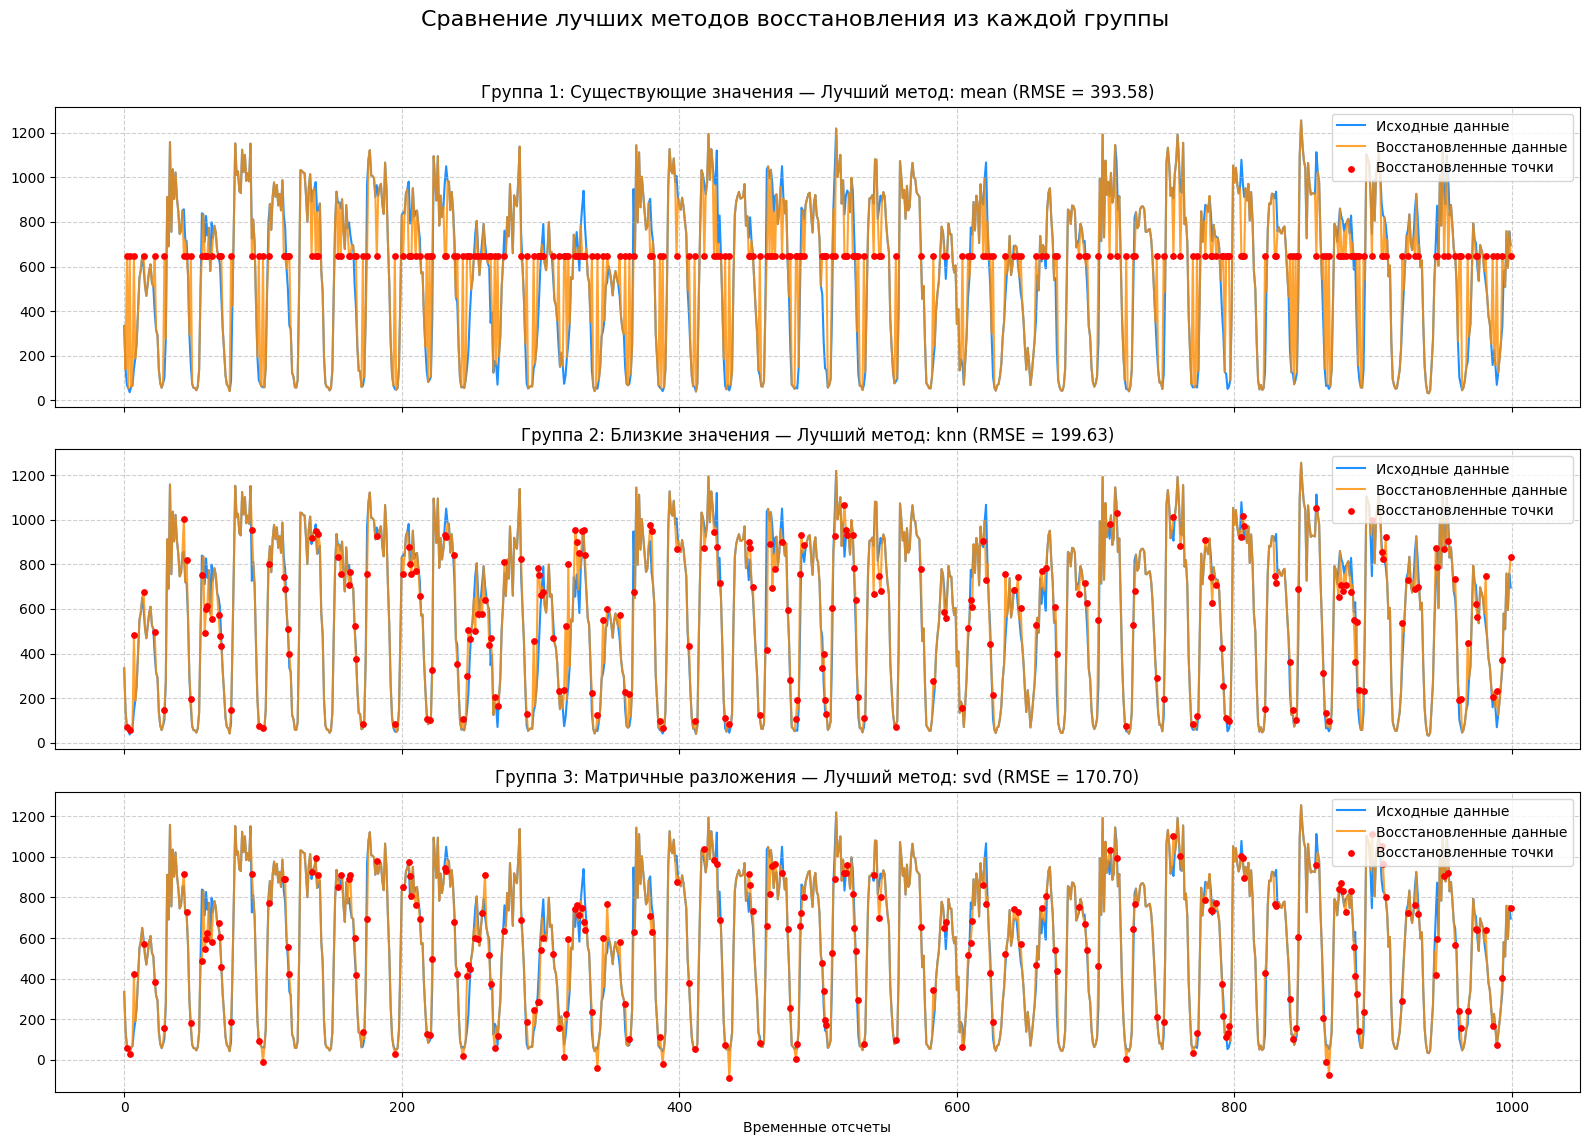

In [52]:
# Определение групп
groups = {
    'Группа 1: Существующие значения': ['mean', 'median', 'hotdeck'],
    'Группа 2: Близкие значения': ['knn'],
    'Группа 3: Матричные разложения': ['svd']
}

best_methods = {}
for group_name, method_list in groups.items():
    # Находим метод с минимальным RMSE в группе
    best_method_name = min(method_list, key=lambda m: metrics[m]['RMSE'])
    best_methods[group_name] = best_method_name

print("Лучшие методы в каждой группе (по RMSE):")
for group, method in best_methods.items():
    print(f"- {group}: {method}")

# Визуализация
fig, axes = plt.subplots(len(best_methods), 1, figsize=(16, 12), sharex=True)
fig.suptitle('Сравнение лучших методов восстановления из каждой группы', fontsize=16)

# Определяем, какие из пропущенных индексов попадают в наш график (первые 1000 точек)
plot_range = 1000
mask_for_plot = index & (np.arange(len(index)) < plot_range)

for i, (group_name, method_name) in enumerate(best_methods.items()):
    ax = axes[i]
    # Исходный ряд
    ax.plot(madrid[:plot_range], label='Исходные данные', color='dodgerblue', zorder=1)
    # Восстановленный ряд
    ax.plot(recovery[method_name][:plot_range], label='Восстановленные данные', color='darkorange', alpha=0.8, zorder=2)
    # Точки, где было восстановление
    ax.scatter(np.where(mask_for_plot)[0], recovery[method_name][mask_for_plot],
               color='red', s=15, label='Восстановленные точки', zorder=3)

    rmse_value = metrics[method_name]['RMSE']
    ax.set_title(f"{group_name} — Лучший метод: {method_name} (RMSE = {rmse_value:.2f})")
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.6)

plt.xlabel("Временные отсчеты")
plt.tight_layout(rect=[0, 0.03, 1, 0.96])
plt.show()

Заполнение средним значением (mean) сильно искажает локальную структуру ряда, так как подставляет одно и то же глобальное среднее в пики и спады. Hot-Deck ведет себя непредсказуемо и может вставить значение из совершенно другой части ряда, что приводит к огромным ошибкам.

Методы KNNImputer и IterativeSVD показывают значительно лучшие результаты (гораздо меньшие значения MAE, MSE и RMSE), чем любой метод из первой группы. Это ожидаемо, поскольку они анализируют структуру данных.

KNN и SVD показывают себя как самые точные методы. KNN восстанавливает пропуски, находя похожие по форме временные окна, что идеально подходит для данных с повторяющимися суточными/недельными паттернами. IterativeSVD улавливает основные компоненты (главные циклы) во всем наборе данных и использует их для восстановления. В данном случае их результаты довльно близки, но svd немного лучше.

#### **7.2 Нейросетевые методы востановления временного ряда**

##### *Краткое описание*

В данном пункте практической работы вам предстоит познакомиться с некоторыми нейросетевыми методами восстановления временных рядов.
Для выполнения данного пункта вам предстоит самостоятельно реализовать структуру нейросетевой, модели основанной на GRU нейронах и сравнить ее с другими нейросетевыми методами восстановления При сравнении с 3 группой из **табл.7. 2** вам необходимо выбрать **один** метод восстановления. Основные блоки обработки данных будут реализованы с использованием Pytorch. Вам не запрещается использовать для реализации Keras.

**табл. 7.2** - Нейросетевые методы восстановления.
№|Название группы|Модели и методы|
--|-------------|----|
1|Линейные нейроны|[Pytorch](https://pytorch.org/docs/stable/generated/torch.nn.Linear.html)|
 2eкрркуретные нейронны|[Pytorch](https://pytorch.org/docs/stable/generated/torch.nn.GRU.html)|
3|Сложные структуры|[SAITS, BRITS, M-RNN](https://github.com/WenjieDu/PyPOTS)|

In [ ]:
recovery_nn = {}

##### 7.2.1 Загрузка и подготовка данных

In [ ]:
path_data = Path('Dataset')/'madrid.txt'
madrid = np.loadtxt(path_data)[:,:]
print(madrid.shape)

(25000, 10)


In [ ]:
madrid_with_nan, index = add_nan(madrid, 0.25)

(25000, 10) (25000, 10)


In [ ]:
madrid_with_nan.shape

(25000, 10)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
madrid_normal_with_nan = scaler.fit_transform(madrid_with_nan)
rolling_madrid = rolling_window(madrid_normal_with_nan, 100, True)
train, test = train_test_split(rolling_madrid,shuffle=False, test_size=0.33)

##### 7.2.2 Базовая модель восстановления данных, построенная на нескольких слоях линейных нейронов.


Вам необходимо будет самостоятельно реализовать:
1. инициализацию nan значений какими либо другими значениями.
2. замер времени полного обучения и тестирования модели.

In [ ]:
import torch
from torch import nn
from torch.utils.data import DataLoader

In [ ]:
class LinearModel(nn.Module):
    def __init__(self, size_subsequent: int,dim = 1, nums_layers = 3, size_layers = 250):
        super().__init__()

        self.size_subsequent = size_subsequent
        self.nums_layers = nums_layers*dim
        self.dim = dim
        self.size_layers = size_layers

        self.start_layers = nn.Sequential(nn.Flatten(),
                                          nn.Linear(size_subsequent*dim, self.size_layers),
                                          nn.LeakyReLU())
        self.model = nn.ModuleList([
                                        (nn.Sequential(
                                                nn.Linear(self.size_layers, self.size_layers), nn.LeakyReLU()
                                            )
                                        )
                                    for x in torch.arange(nums_layers)])
        self.model = nn.Sequential(*self.model)

        self.output = nn.Sequential(nn.Linear(self.size_layers,size_subsequent*dim),nn.Tanh())

    def forward(self, x):
        x = self.start_layers(x)

        x=self.model(x)
        x=self.output(x)
        return x.reshape(x.shape[0],self.size_subsequent,self.dim)

In [ ]:
model = LinearModel(size_subsequent=train.shape[1],dim=train.shape[2])
optimizer = torch.optim.Adam(model.parameters(),lr=1.0e-3)
loss_func = nn.MSELoss()
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
batch_size = 64
percent = 0.25

train_loader = DataLoader(train,batch_size=batch_size,shuffle=True)
valid_loader = DataLoader(test,batch_size=batch_size,shuffle=True)

print(train.shape,test.shape)
epochs = 100

(16683, 100, 10) (8217, 100, 10)


In [ ]:
model

LinearModel(
  (start_layers): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=1000, out_features=250, bias=True)
    (2): LeakyReLU(negative_slope=0.01)
  )
  (model): Sequential(
    (0): Sequential(
      (0): Linear(in_features=250, out_features=250, bias=True)
      (1): LeakyReLU(negative_slope=0.01)
    )
    (1): Sequential(
      (0): Linear(in_features=250, out_features=250, bias=True)
      (1): LeakyReLU(negative_slope=0.01)
    )
    (2): Sequential(
      (0): Linear(in_features=250, out_features=250, bias=True)
      (1): LeakyReLU(negative_slope=0.01)
    )
  )
  (output): Sequential(
    (0): Linear(in_features=250, out_features=1000, bias=True)
    (1): Tanh()
  )
)

In [ ]:
import time
times_model = {}

In [ ]:
model=model.to(device)
train_history = []
valid_history = []

start = time.time()
for epoch in np.arange(epochs):
    train_loss =0
    valid_loss =0

    for i, x in enumerate(train_loader):
        if x.shape[0] == batch_size:
            optimizer.zero_grad()
            x = x.to(device).to(torch.float32)
            test_index = np.isnan(x.cpu().numpy())
            X = x.clone()
            X, nan = add_nan(X,percent)
            ###вставте инициализацию нулями nan значений
            recovery = model(X)
            loss = loss_func(recovery[(nan)&(~test_index)],x[(nan)&(~test_index)])
            train_loss += loss.detach().cpu().item()
            loss.backward()
            optimizer.step()
    train_loss/=(i+1)
    print('valid')
    with torch.no_grad():
        for i, x in enumerate(valid_loader):
            if x.shape[0] == batch_size:
                x = x.to(device).to(torch.float32)
                test_index = np.isnan(x.cpu().numpy())
                X = x.clone()
                X, nan = add_nan(X,percent)
                X[torch.isnan(X)]=0.0
                recovery = model(X)
                loss = loss_func(recovery[(nan)&(~test_index)],x[(nan)&(~test_index)])
                valid_loss += loss.detach().cpu().item()
    valid_loss/=(i+1)
    train_history.append(train_loss)
    valid_history.append(valid_loss)
    print(f'epoch:{epoch+1} train:{train_loss}, valid:{valid_loss}')
end = time.time()

valid
epoch:1 train:0.01611318807492311, valid:0.008655089661190215
valid
epoch:2 train:0.008517843498081197, valid:0.007346930891968483
valid
epoch:3 train:0.006750307350965409, valid:0.005705035605662784
valid
epoch:4 train:0.005377719610558387, valid:0.00529541350655662
valid
epoch:5 train:0.00477882488755602, valid:0.004763821233785891
valid
epoch:6 train:0.004289024376570893, valid:0.004202899887666915
valid
epoch:7 train:0.0039321740025875665, valid:0.004013050436006151
valid
epoch:8 train:0.0036666128058271963, valid:0.0037690944312674594
valid
epoch:9 train:0.0034416405880160032, valid:0.003823137316896125
valid
epoch:10 train:0.003276596601403022, valid:0.0035195500398588968
valid
epoch:11 train:0.003150434458942306, valid:0.0034511806948702463
valid
epoch:12 train:0.0029987307690026886, valid:0.0032823553900848063
valid
epoch:13 train:0.0028882348157065808, valid:0.003274920024699712
valid
epoch:14 train:0.0027794978675928497, valid:0.003105788782253399
valid
epoch:15 train:0

In [ ]:
times_model['linear']=end-start

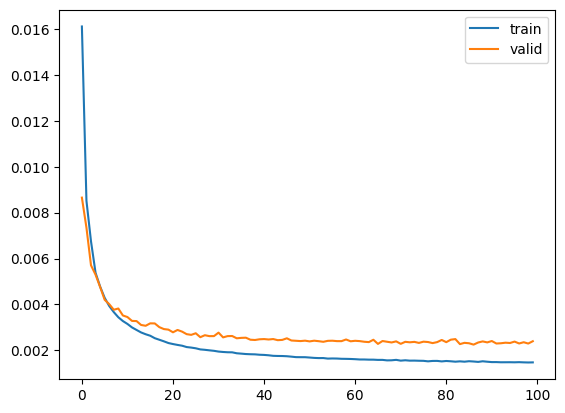

In [ ]:
plt.plot(train_history,label='train')
plt.plot(valid_history,label='valid')
plt.legend()
plt.show()

In [ ]:
test_rolling_madrid = rolling_window(madrid_normal_with_nan, 100, False)
#test = []
with torch.no_grad():
    for idx, batch in enumerate(test_rolling_madrid):
        batch = torch.Tensor(batch).to(device)
        nan = torch.isnan(batch)
        batch[nan]=0.0
        rec = model(batch[None,:])[0].cpu().numpy()
        nan = nan.cpu().numpy()
        test_rolling_madrid[idx][nan]=rec[nan]

In [ ]:
test_madrid_normal = np.vstack(test_rolling_madrid)
test_linear = scaler.inverse_transform(test_madrid_normal)

In [ ]:
recovery_nn['linear'] = test_linear

19223.47670004051


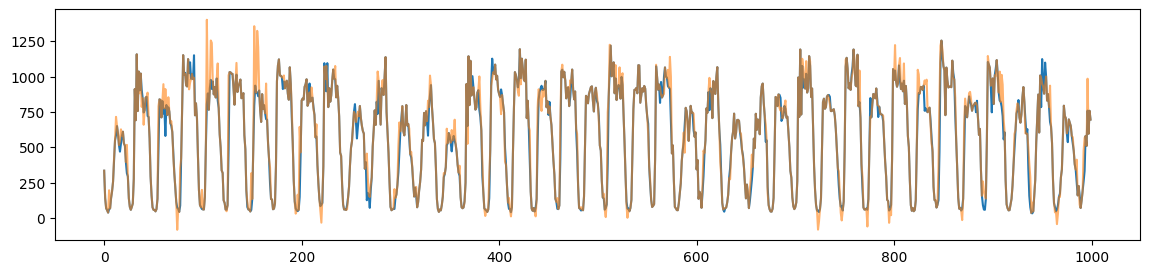

In [ ]:
fig, ax =  plt.subplots(figsize=(14,3),ncols=1,nrows=1)

plt.plot(madrid[:1000,0])
plt.plot(test_linear[:1000,0],alpha=0.6)
print(mean_squared_error(madrid[index].reshape(1,-1),test_linear[index].reshape(1,-1)))

##### 7.2.3 Реккурентная модель востановлениях данных


In [ ]:
class EncoderGRU(nn.Module):
    def __init__(self, size_subsequent: int, dim = 1, latten_size = 100, hidden_size=100):
        super().__init__()
        self.size_subsequent=size_subsequent
        self.dim = dim
        self.hidden_size = hidden_size
        self.gru = nn.GRU(input_size=dim,
                          hidden_size=self.hidden_size)

        self.latten = nn.Linear(hidden_size*size_subsequent,latten_size)
        self.leaky = nn.LeakyReLU()
        self.fl = nn.Flatten()
    def forward(self, x):
        x, _ = self.gru(x)
        x = self.leaky(x)
        #print(x.shape)
        x = self.fl(x)
        x = self.latten(x)
        return self.leaky(x)


In [ ]:
class DecoderGRU(nn.Module):
    def __init__(self, size_subsequent: int, dim = 1, latten_size = 100, hidden_size=100):
        super().__init__()
        self.size_subsequent=size_subsequent
        self.dim = dim
        self.hidden_size = hidden_size
        self.latten_size=latten_size
        self.gru = nn.GRU(input_size=self.hidden_size,
                          hidden_size=dim)
        self.latten = nn.Linear(latten_size,hidden_size*size_subsequent)
        self.leaky = nn.LeakyReLU()

    def forward(self, x):
        x = self.latten(x)
        x = x.view(-1, self.size_subsequent, self.latten_size)
        x = self.leaky(x)
        x, _ = self.gru(x)
        return self.leaky(x)


In [ ]:
class TimeAE(nn.Module):
    def __init__(self, size_subsequent: int, dim = 1, latten_size = 100, hidden_size=100):
        super().__init__()
        self.encoder = EncoderGRU(size_subsequent=size_subsequent,
                                 dim=dim,
                                 latten_size=latten_size,
                                 hidden_size=hidden_size)
        self.decoder = DecoderGRU(size_subsequent=size_subsequent,
                                 dim=dim,
                                 latten_size=latten_size,
                                 hidden_size=hidden_size)
    def forward(self, x):
        x=self.encoder(x)
        x = self.decoder(x)
        return x

In [ ]:
model = TimeAE(size_subsequent=train.shape[1],dim=train.shape[2])
optimizer = torch.optim.Adam(model.parameters(),lr=1.0e-3)
loss_func = nn.MSELoss()
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
batch_size = 64
percent = 0.25

train_loader = DataLoader(train,batch_size=batch_size,shuffle=True)
valid_loader = DataLoader(test,batch_size=batch_size,shuffle=True)


epochs = 100

In [ ]:
model

TimeAE(
  (encoder): EncoderGRU(
    (gru): GRU(10, 100)
    (latten): Linear(in_features=10000, out_features=100, bias=True)
    (leaky): LeakyReLU(negative_slope=0.01)
    (fl): Flatten(start_dim=1, end_dim=-1)
  )
  (decoder): DecoderGRU(
    (gru): GRU(100, 10)
    (latten): Linear(in_features=100, out_features=10000, bias=True)
    (leaky): LeakyReLU(negative_slope=0.01)
  )
)

In [ ]:
model=model.to(device)
train_history = []
valid_history = []
start = time.time()
for epoch in np.arange(epochs):
    train_loss =0
    valid_loss =0

    for i, x in enumerate(train_loader):
        if x.shape[0]==batch_size:
            optimizer.zero_grad()
            x = x.to(device).to(torch.float32)
            test_index = np.isnan(x.cpu().numpy())
            X = x.clone()
            X, nan = add_nan(X,percent)
            #

            recovery = model(X)
            loss = loss_func(recovery[(nan)&(~test_index)],x[(nan)&(~test_index)])
            train_loss += loss.detach().cpu().item()
            loss.backward()
            optimizer.step()
    train_loss/=(i+1)
    with torch.no_grad():
        for i, x in enumerate(valid_loader):
            if x.shape[0]==batch_size:
                x = x.to(device).to(torch.float32)
                test_index = np.isnan(x.cpu().numpy())
                X = x.clone()
                X, nan = add_nan(X,percent)
                #

                recovery = model(X)
                loss = loss_func(recovery[(nan)&(~test_index)],x[(nan)&(~test_index)])
                valid_loss += loss.detach().cpu().item()
    valid_loss/=(i+1)
    train_history.append(train_loss)
    valid_history.append(valid_loss)
    print(f'epoch:{epoch+1} train:{train_loss}, valid:{valid_loss}')
end = time.time()

epoch:1 train:0.005667857565271215, valid:0.0048371934866200585
epoch:2 train:0.00420799586293912, valid:0.004097167624507186
epoch:3 train:0.0035405969621891947, valid:0.003608167110112055
epoch:4 train:0.003133067681893021, valid:0.0032865865636154895
epoch:5 train:0.002844720459775107, valid:0.0030663977774192195
epoch:6 train:0.0026280734780819025, valid:0.0028908427194656097
epoch:7 train:0.0024395643169652687, valid:0.002762273224720428
epoch:8 train:0.002310831576114756, valid:0.002648445248762651
epoch:9 train:0.0021598582576168165, valid:0.002507162047550082
epoch:10 train:0.0020520448929119955, valid:0.002424571598165257
epoch:11 train:0.0019568192395221055, valid:0.002385350184284093
epoch:12 train:0.0018743742489295216, valid:0.0022636219126338413
epoch:13 train:0.0018025992480124493, valid:0.0022381309459577926
epoch:14 train:0.001751357673888605, valid:0.002197221281591716
epoch:15 train:0.0016929136809511146, valid:0.002117336496653021
epoch:16 train:0.001646642735534815

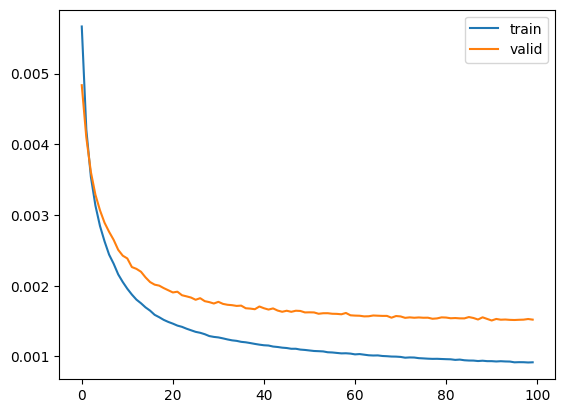

In [ ]:
plt.plot(train_history,label='train')
plt.plot(valid_history,label='valid')
plt.legend()
plt.show()

In [ ]:
times_model['ae']=end-start

In [ ]:
test_rolling_madrid = rolling_window(madrid_normal_with_nan, 100, False)
#test = []
with torch.no_grad():
    for idx, batch in enumerate(test_rolling_madrid):
        batch = torch.Tensor(batch).to(device)
        nan = torch.isnan(batch)
        #

        rec = model(batch[None,:])[0].cpu().numpy()
        nan = nan.cpu().numpy()
        test_rolling_madrid[idx][nan]=rec[nan]

In [ ]:
test_madrid_normal = np.vstack(test_rolling_madrid)
test_ae = scaler.inverse_transform(test_madrid_normal)

In [ ]:
recovery_nn['test_ae'] = test_ae

7815.347353696892


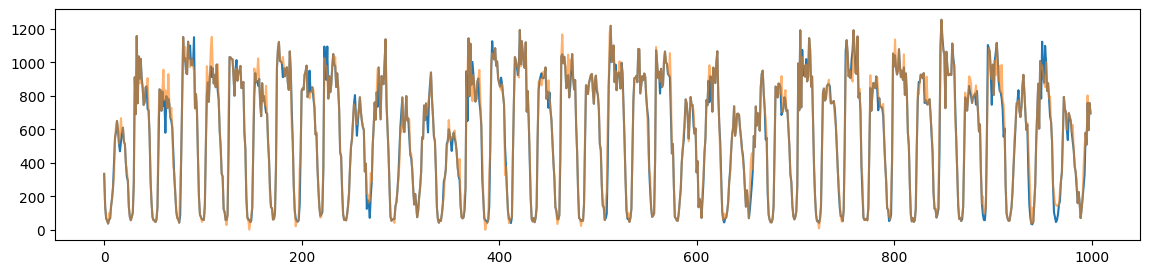

In [ ]:
fig, ax =  plt.subplots(figsize=(14,3),ncols=1,nrows=1)

plt.plot(madrid[:1000,0])
plt.plot(test_ae[:1000,0],alpha=0.6)
print(mean_squared_error(madrid[index].reshape(1,-1),test_ae[index].reshape(1,-1)))

##### 7.2.4 Сложные модели нейросетевого восстановления данных


Вам необходимо выбрать одну модель из 3 группы таблицы 7.2 и используя документацию произвести восстановления того же ряда. Произведите замер времени.

In [ ]:
!pip install pypots==0.0.9

In [ ]:
from pypots.imputation import SAITS


In [ ]:
model= SAITS(n_features=madrid.shape[1],
             n_steps=100,
             device=device,
             d_k=64,
             d_v=64,
             d_model=128,
             d_inner=128,
             n_head=4,
             n_layers=2,
             dropout=0.05,
             epochs=100)

Model initialized successfully. Number of the trainable parameters: 667608


In [ ]:
start = time.time()
model.fit(train,test)
end = time.time()
times_model['saits']=end-start

epoch 0: training loss 0.1332, validating loss 0.0487
epoch 1: training loss 0.0748, validating loss 0.0418


In [ ]:
test_rolling_madrid = rolling_window(madrid_normal_with_nan, 100, False)
test_rolling_madrid = model.impute(test_rolling_madrid)


In [ ]:
test_madrid_normal = np.vstack(test_rolling_madrid)
test_saits = scaler.inverse_transform(test_madrid_normal)

In [ ]:
recovery_nn['saits'] = test_saits

4653.035675034267


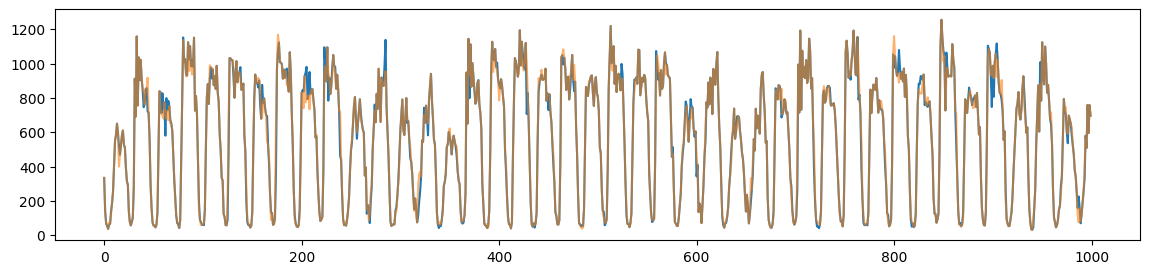

In [ ]:
fig, ax =  plt.subplots(figsize=(14,3),ncols=1,nrows=1)

plt.plot(madrid[:1000,0])
plt.plot(test_saits[:1000,0],alpha=0.6)
print(mean_squared_error(madrid[index].reshape(1,-1),test_saits[index].reshape(1,-1)))

##### 7.2.5 Сравнения результатов.
Также, как и в пункте 7.1.5 постройте графики сравнения моделей. Дополнительно постройте графики сравнения времени. Сделайте выводы

#### **7.3 Прогноз временного ряда**

##### *Краткое описание*

Используя модель и [ARIMA](реализация) произвидите прогноз ряда на следующие колличество точек: 1, 5, 10.
Сравните результаты. Постройте графики прогноза и точности прогноза.